# Surface water mass transformations from surface fluxes and surface properties only

Most water mass transformation analyses need the ocean interior: 3D tracer fields, layer
thicknesses, and the full set of tendency terms. Often you don't have any of that. Surface
fluxes and surface properties are the fields that get saved, published, and shared; the
interior is what gets dropped.

This notebook is the surface-only story. It shows how to compute **surface water mass
transformation (SWMT)** — and decompose it into the individual air-sea and ice-ocean
processes that drive it — from 2D fields alone, and it explains the assumption that makes
this possible.

## What you'll learn

1. How to load a surface-only MOM6 dataset and build the `xbudget` surface budget preset
   (`model="MOM6_surface"`), decomposed into individual flux processes.
2. Why deleting the 3D `lambda` entries is what switches `xwmt` into its surface-only
   mode — the central mechanism of this notebook, and the one thing that makes everything
   below work.
3. How `xwmt` actually implements that mode, via the `WaterMass` helpers
   `get_outcrop_lev` / `sel_outcrop_lev` (including the `incrop=True` seafloor
   counterpart and `min_thickness`) and `expand_surface_array_vertically`.
4. How to integrate and plot SWMT in $\sigma_{2}$ space, decomposed by process
   (evaporation, rain, rivers, icebergs, sea-ice melt, surface heat fluxes, ...).

## Prerequisites

Start with [quickstart.ipynb](./quickstart.ipynb) — it introduces `WaterMassTransformations`,
the budget dictionary, and $\lambda$-space binning on a small dataset. This notebook assumes
you have seen those.

## Data

**1.20 GB** · downloads once (cached in `../data/`) · runs in ~30 s once downloaded

The dataset is 12 monthly means from a global MOM6 simulation, on the **native 1440 × 1080
horizontal grid**, containing only surface temperature (`tos`), surface salinity (`sos`), and
the surface fluxes of heat, salt, and freshwater. It is downloaded automatically from
[Zenodo record 15420739](https://zenodo.org/record/15420739).

Note this is a **different file** from the one used by `closed_transformation_budget.ipynb` and
`north_atlantic_deep_water.ipynb` (`MOM6_global_example_sigma2_budgets_v0_0_6.nc`), which is
coarsened horizontally but retains the full interior in density layers. This one makes the
opposite trade: full horizontal resolution, no interior at all.

## Import packages

In [1]:
import warnings
import numpy as np
import xarray as xr
import xbudget
from xgcm import Grid
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt

# Warnings are rendered without their absolute source path. The default format
# prefixes each with the file that raised it, which would bake whoever-ran-this's
# home directory into the committed output and the published documentation.
warnings.formatwarning = lambda msg, cat, *_, **__: f"{cat.__name__}: {msg}\n"


In [2]:
import xwmt
print('xwmt version', xwmt.__version__)

xwmt version 0.3.0


## Load surface diagnostics

Suppose no interior information is available, as in the dataset loaded below that only include surface temperature, surface salinity, and surface fluxes of heat, salt, and freshwater.

In [3]:
from load_example_model_grid import load_MOM6_surface_diagnostics
grid = load_MOM6_surface_diagnostics()
ds = grid._ds

File 'MOM6_global_example_surface_fluxes_v0_0_7.nc' already exists at data/MOM6_global_example_surface_fluxes_v0_0_7.nc. Skipping download.


Before going further, it is worth confirming just how little this dataset contains. The
`xgcm.Grid` has **no Z axis at all** — there is no vertical coordinate, no layer
thickness, and therefore no notion of an ocean interior:

In [4]:
print("grid axes:      ", list(grid.axes))
print("dataset dims:   ", dict(ds.sizes))
print("data variables: ", list(ds.data_vars))

grid axes:       ['X', 'Y']
dataset dims:    {'time': 12, 'yh': 1080, 'xh': 1440, 'nv': 2, 'z_i': 36, 'time_bounds': 61, 'yq': 1081, 'xq': 1441}
data variables:  ['evs', 'ficeberg', 'friver', 'fsitherm', 'hflso', 'hfsso', 'prlq', 'prsn', 'rlntds', 'sfdsi', 'sos', 'tos', 'vprec', 'wfo', 'rsntds']


Every field we will use is a function of `(time, yh, xh)` only. `tos` and `sos` are the
surface $\lambda$ ingredients; the rest are surface fluxes of heat, salt, or freshwater.

## Aggregate the terms in the budget dictionary

`xbudget` ships a preset budget for MOM6 surface diagnostics. `load_preset_budget` returns
the template; `collect_budgets` matches the template against the variables actually present in
`ds` and sums the matching diagnostics into named budget terms.

In [5]:
xbudget_dict = xbudget.load_preset_budget(model="MOM6_surface")
xbudget.collect_budgets(ds, xbudget_dict)

<xarray.Dataset> Size: 4GB
Dimensions:                                                                      (
                                                                                  time: 12,
                                                                                  yh: 1080,
                                                                                  xh: 1440,
                                                                                  nv: 2,
                                                                                  z_i: 36,
                                                                                  time_bounds: 61,
                                                                                  yq: 1081,
                                                                                  xq: 1441)
Coordinates: (12/27)
  * time                                                                         (time) object 96B ...
    time_since_init                                                              (time) object 96B dask.array<chunksize=(12,), meta=np.ndarray>
  * yh                                                                           (yh) int64 9kB ...
    dyCu                                                                         (xq, yh) float32 6MB dask.array<chunksize=(1441, 1080), meta=np.ndarray>
  * xh                                                                           (xh) int64 12kB ...
    areacello                                                                    (yh, xh) float32 6MB dask.array<chunksize=(1080, 1440), meta=np.ndarray>
    ...                                                                           ...
  * xq                                                                           (xq) int64 12kB ...
    geolon_u                                                                     (yh, xq) float64 12MB dask.array<chunksize=(1080, 1441), meta=np.ndarray>
    geolat_u                                                                     (yh, xq) float64 12MB dask.array<chunksize=(1080, 1441), meta=np.ndarray>
    geolon_c                                                                     (yq, xq) float64 12MB dask.array<chunksize=(1081, 1441), meta=np.ndarray>
    geolat_c                                                                     (yq, xq) float64 12MB dask.array<chunksize=(1081, 1441), meta=np.ndarray>
    wet_u                                                                        (yh, xq) float32 6MB dask.array<chunksize=(1080, 1441), meta=np.ndarray>
Data variables: (12/46)
    evs                                                                          (time, yh, xh) float32 75MB dask.array<chunksize=(12, 1080, 1440), meta=np.ndarray>
    ficeberg                                                                     (time, yh, xh) float32 75MB dask.array<chunksize=(12, 1080, 1440), meta=np.ndarray>
    friver                                                                       (time, yh, xh) float32 75MB dask.array<chunksize=(12, 1080, 1440), meta=np.ndarray>
    fsitherm                                                                     (time, yh, xh) float32 75MB dask.array<chunksize=(12, 1080, 1440), meta=np.ndarray>
    hflso                                                                        (time, yh, xh) float32 75MB dask.array<chunksize=(12, 1080, 1440), meta=np.ndarray>
    hfsso                                                                        (time, yh, xh) float32 75MB dask.array<chunksize=(12, 1080, 1440), meta=np.ndarray>
    ...                                                                           ...
    salt_rhs_surface_ocean_flux_advective_negative_rhs_rivers                    (time, yh, xh) float32 75MB dask.array<chunksize=(12, 1080, 1440), meta=np.ndarray>
    salt_rhs_surface_ocean_flux_advective_negative_rhs_icebergs                  (time, yh, xh) float32 75MB dask.array<chunksize=(12, 1080, 1440), 

`aggregate` then collapses the budget tree into a flat dictionary of terms. Passing
`decompose=[...]` tells it *not* to collapse the listed branches, so each individual process
(evaporation, rivers, icebergs, sea-ice melt, ...) survives as its own term rather than being
summed into a single lumped surface flux. This is what lets us attribute the transformation to
specific physical processes at the end.

In [6]:
# decompose all surface flux terms as much as possible
decompose_list = ["surface_exchange_flux", "advective", "surface_ocean_flux_advective_negative_rhs"]
decomposed_budgets = xbudget.BudgetQuery(ds, xbudget_dict).aggregate(decompose=decompose_list)

## The key step: deleting the 3D `lambda` entries

The next cell is the hinge of this entire notebook, and it deserves a real explanation rather
than being an unexplained incantation.

Each tracer's budget dictionary can carry **two** different $\lambda$ (tracer) keys:

- `lambda` — the name of the **3D** tracer field (e.g. `thetao`, `so`), defined throughout the
  water column;
- `surface_lambda` — the name of the **2D surface** tracer field (e.g. `tos`, `sos`).

The `MOM6_surface` preset populates *both*, because the preset is written generically. But the
3D fields it names simply **do not exist in this dataset** — we only have `tos` and `sos`.
Leaving the `lambda` entries in place would have `xwmt` look for interior tracer fields it
cannot find.

Deleting them is how we tell `xwmt` "there is no interior here." When
`WaterMassTransformations` builds its tracer mapping, it checks for `lambda` first and falls
back to `surface_lambda` only when `lambda` is absent (in `xwmt/wmt.py`):

```python
if "lambda" in xbudget_dict[tracer]:
    ...                                              # 3D path
elif "surface_lambda" in xbudget_dict[tracer]:
    self.tracer_dict[tracer] = xbudget_dict[tracer]["surface_lambda"]
```

So the deletion is not a cleanup detail — **it is the switch that selects the surface-only
code path.** With no 3D `lambda`, and with tendency terms that carry no vertical coordinate,
`xwmt` assumes the surface fluxes converge within a single surface layer and bins them in
$\lambda$ space using the **surface** $\lambda$ values (`tos`, `sos`) rather than interior
ones.

That assumption is the price of admission for a surface-only analysis. It is a good one for
air-sea and ice-ocean fluxes, which really do deposit their heat and salt in a thin surface
layer. It says nothing about interior mixing, which this dataset cannot see at all — so what
we compute below is a *surface* water mass transformation, not a closed transformation
budget.

In [7]:
# Drop the 3D tracer ("lambda") entries: the fields they name (`thetao`, `so`) do not exist
# in this surface-only dataset. This is what makes xwmt fall back to `surface_lambda`
# (`tos`, `sos`) and take the surface-only path described above.
del decomposed_budgets['heat']['lambda']
del decomposed_budgets['salt']['lambda']
del decomposed_budgets['mass']['lambda']

# What now identifies the tracer for each budget: `surface_lambda` instead of `lambda`.
for tracer in ['heat', 'salt', 'mass']:
    print(tracer, '->', {k: v for k, v in decomposed_budgets[tracer].items()
                         if k not in ('lhs', 'rhs')})

heat -> {'surface_lambda': 'tos'}
salt -> {'surface_lambda': 'sos'}
mass -> {'thickness': 'thkcello'}


While we can no longer evaluate the full water mass transformation budget, we can still
accurately estimate all of the surface water mass transformation terms this way. `xwmt` does
this automatically when the 3D `lambda` fields are missing from the `budgets_dict` argument of
`WaterMassTransformations` and when the tendencies do not depend on any vertical coordinate.

With that done, we can build the `WaterMassTransformations` object and see which processes are
available to us:

In [8]:
wmt = xwmt.WaterMassTransformations(grid, decomposed_budgets)
sorted(wmt.available_processes())

['surface_exchange_flux_advective',
 'surface_exchange_flux_evaporation',
 'surface_exchange_flux_icebergs',
 'surface_exchange_flux_nonadvective',
 'surface_exchange_flux_rain_and_ice',
 'surface_exchange_flux_rivers',
 'surface_exchange_flux_sea_ice_melt',
 'surface_exchange_flux_snow',
 'surface_exchange_flux_virtual_precip_restoring',
 'surface_ocean_flux_advective_negative_rhs',
 'surface_ocean_flux_advective_negative_rhs_evaporation',
 'surface_ocean_flux_advective_negative_rhs_icebergs',
 'surface_ocean_flux_advective_negative_rhs_rain_and_ice',
 'surface_ocean_flux_advective_negative_rhs_rivers',
 'surface_ocean_flux_advective_negative_rhs_sea_ice_melt',
 'surface_ocean_flux_advective_negative_rhs_snow',
 'surface_ocean_flux_advective_negative_rhs_virtual_precip_restoring']

Each of those names is a distinct physical process exchanging heat, salt, or freshwater across
the ocean surface. The full budget dictionary shows which model diagnostic each one maps to —
and, at the top of each tracer, the `surface_lambda` entry that survived the deletion:

In [9]:
decomposed_budgets

{'mass': {'thickness': 'thkcello',
  'lhs': {},
  'rhs': {'surface_exchange_flux_rain_and_ice': 'mass_rhs_surface_exchange_flux_rain_and_ice',
   'surface_exchange_flux_snow': 'mass_rhs_surface_exchange_flux_snow',
   'surface_exchange_flux_evaporation': 'mass_rhs_surface_exchange_flux_evaporation',
   'surface_exchange_flux_rivers': 'mass_rhs_surface_exchange_flux_rivers',
   'surface_exchange_flux_icebergs': 'mass_rhs_surface_exchange_flux_icebergs',
   'surface_exchange_flux_sea_ice_melt': 'mass_rhs_surface_exchange_flux_sea_ice_melt',
   'surface_exchange_flux_virtual_precip_restoring': 'mass_rhs_surface_exchange_flux_virtual_precip_restoring'}},
 'heat': {'surface_lambda': 'tos',
  'lhs': {},
  'rhs': {'surface_exchange_flux_nonadvective': 'heat_rhs_surface_exchange_flux_nonadvective',
   'surface_exchange_flux_advective': 'heat_rhs_surface_exchange_flux_advective',
   'surface_ocean_flux_advective_negative_rhs': 'heat_rhs_surface_ocean_flux_advective_negative_rhs'}},
 'salt': {'s

## Under the hood: how a 2D flux becomes a layer tendency

The prose above says `xwmt` "assumes the surface fluxes converge in a surface layer." That
sentence hides some real machinery, which is worth opening up — it is the mechanism this whole
notebook rests on.

`WaterMassTransformations` inherits from `WaterMass`, which provides three relevant helpers:

- `get_outcrop_lev()` — the vertical level of the first cell with non-vanishing thickness,
  searching from the sea surface downward (the *outcropping* layer). With `incrop=True` it
  searches from the seafloor upward instead, giving the bottom-most real cell — the natural
  counterpart for geothermal fluxes and bottom-water analyses. `min_thickness` (default
  `1e-6`) sets how thick a cell must be to count as "real", which matters in models like MOM6
  where layers routinely vanish to zero thickness.
- `sel_outcrop_lev(da)` — selects a 3D field `da` at that diagnosed level, returning a 2D
  field.
- `expand_surface_array_vertically(da_surf)` — the inverse: takes a 2D surface field and
  expands it in the vertical, placing its values in the outcropping layer and **zero
  everywhere else**.

That last one is exactly what `xwmt` does to each surface flux internally (in
`WaterMassTransformations.datadict`):

```python
scalar = self.grid._ds[tracer_name]
if self.grid.axes["Z"].coords["center"] not in scalar.dims:
    scalar = self.expand_surface_array_vertically(scalar, target_position="center")
...
if n_zcoords == 0:
    tend_arr = self.expand_surface_array_vertically(tend_arr, target_position="center")
```

A 2D flux with zeros below it *is* the statement "this flux converges entirely in the
outcropping layer." The assumption is not buried in a formula; it is literally this array
operation.

### On this dataset, the vertical grid is a single synthetic layer

Our grid had no `Z` axis. `WaterMass` handles this by **synthesising a one-layer vertical
grid**, so that the same code path works for 2D and 3D data alike. We can inspect what it
built:

In [10]:
print("wmt.grid axes:  ", list(wmt.grid.axes))
print("Z center coord: ", wmt._zc, "=", wmt.grid._ds[wmt._zc].values)
print("Z outer coord:  ", wmt._zi, "=", wmt.grid._ds[wmt._zi].values)
print("layer thickness (center):", wmt.Z_metrics["center"].values)

wmt.grid axes:   ['X', 'Y', 'Z']
Z center coord:  z_l = [0.5]
Z outer coord:   z_i = [0. 1.]
layer thickness (center): [1]


A single layer centred at `z_l = 0.5` with unit thickness. The outcrop helpers therefore run
happily here, but they are **degenerate**: with only one layer, the first thick cell counting
down from the surface and the first thick cell counting up from the seafloor are the same
cell, so `incrop=True` returns the identical answer. The round trip through
`expand_surface_array_vertically` → `sel_outcrop_lev` is likewise an identity.

In [11]:
print("outcrop level (surface -> down):", float(wmt.get_outcrop_lev(position="center")))
print("incrop  level (bottom  -> up)  :", float(wmt.get_outcrop_lev(position="center", incrop=True)))

# The round trip: expand `tos` vertically, then select it back at the outcropping level.
tos_3d = wmt.expand_surface_array_vertically(wmt.grid._ds["tos"], target_position="center")
tos_back = wmt.sel_outcrop_lev(tos_3d)

print("\ntos           dims:", wmt.grid._ds["tos"].dims)
print("expanded      dims:", tos_3d.dims)
print("selected back dims:", tos_back.dims)
print("round trip recovers the original field:",
      bool(np.allclose(tos_back.isel(time=0), wmt.grid._ds["tos"].isel(time=0), equal_nan=True)))

outcrop level (surface -> down): 0.5
incrop  level (bottom  -> up)  : 0.5

tos           dims: ('time', 'yh', 'xh')
expanded      dims: ('z_l', 'time', 'yh', 'xh')
selected back dims: ('time', 'yh', 'xh')


round trip recovers the original field: True


### A synthetic 3D grid, where the helpers do something interesting

Because this dataset is surface-only, the helpers above cannot show what they are actually
*for*. So we build a tiny synthetic 3D grid inline: three columns and five vertical levels,
with vanishing layers of the kind a real isopycnal model produces.

- **Column 0** has vanished layers at the top and bottom — the water column occupies levels 1–2.
- **Column 1** has a thin (20 m) top layer and a vanished bottom layer.
- **Column 2** is dry land: every layer has zero thickness.

In [12]:
nz, ny, nx = 5, 1, 3

# Layer thicknesses [m]; zeros are vanished layers.
h = np.zeros((nz, ny, nx))
h[:, 0, 0] = [0.,  50., 50.,  0.,  0.]   # vanished at top and bottom
h[:, 0, 1] = [20., 30., 40., 60.,  0.]   # thin top layer, vanished at bottom
h[:, 0, 2] = [0.,   0.,  0.,  0.,  0.]   # land

thetao = np.tile(np.array([20., 15., 10., 5., 2.])[:, None, None], (1, ny, nx))

ds_synth = xr.Dataset(
    {
        "thkcello":  (("z_l", "yh", "xh"), h),
        "thetao":    (("z_l", "yh", "xh"), thetao),
        "so":        (("z_l", "yh", "xh"), np.full((nz, ny, nx), 35.)),
        "areacello": (("yh", "xh"), np.full((ny, nx), 1e6)),
    },
    coords={
        "z_l": np.arange(nz) + 0.5, "z_i": np.arange(nz + 1).astype(float),
        "xh":  np.arange(nx) + 0.5, "xq":  np.arange(nx + 1).astype(float),
        "yh":  np.arange(ny) + 0.5, "yq":  np.arange(ny + 1).astype(float),
        "lat": (("yh", "xh"), np.zeros((ny, nx))),
    },
).chunk(-1)

grid_synth = Grid(
    ds_synth,
    coords={
        "X": {"center": "xh", "outer": "xq"},
        "Y": {"center": "yh", "outer": "yq"},
        "Z": {"center": "z_l", "outer": "z_i"},
    },
    metrics={("X", "Y"): "areacello"},
    padding={"X": "periodic", "Y": "extend", "Z": "extend"},
    autoparse_metadata=False,
)

wm_synth = xwmt.WaterMass(grid_synth)

# Layer thicknesses: rows are vertical levels, columns are the three water columns.
ds_synth.thkcello.squeeze("yh").to_pandas()

xh,0.5,1.5,2.5
z_l,,,
0.5,0.0,20.0,0.0
1.5,50.0,30.0,0.0
2.5,50.0,40.0,0.0
3.5,0.0,60.0,0.0
4.5,0.0,0.0,0.0


Now `get_outcrop_lev` and its `incrop=True` counterpart pick out genuinely different levels.
Note that the land column returns `NaN`: no layer anywhere in it exceeds `min_thickness`, so
there is nothing to select.

In [13]:
outcrop = wm_synth.get_outcrop_lev(position="center")
incrop  = wm_synth.get_outcrop_lev(position="center", incrop=True)

print("outcrop level (first thick cell from the surface): ", outcrop.values.squeeze())
print("incrop  level (first thick cell from the seafloor):", incrop.values.squeeze())
print("                                                    (NaN = land column)")

# `min_thickness` sets the bar for what counts as a "real" cell. Raising it to 25 m
# disqualifies column 1's thin 20 m top layer, pushing its outcrop down a level.
print("\noutcrop, min_thickness=1e-6 (default):",
      wm_synth.get_outcrop_lev(position="center", min_thickness=1e-6).values.squeeze())
print("outcrop, min_thickness=25.:           ",
      wm_synth.get_outcrop_lev(position="center", min_thickness=25.).values.squeeze())

outcrop level (first thick cell from the surface):  [1.5 0.5 nan]
incrop  level (first thick cell from the seafloor): [2.5 3.5 nan]
                                                    (NaN = land column)

outcrop, min_thickness=1e-6 (default): [1.5 0.5 nan]
outcrop, min_thickness=25.:            [1.5 1.5 nan]


`sel_outcrop_lev` uses those levels to sample a 3D field at the surface-most and bottom-most
real cells — the sea-surface temperature and the bottom temperature respectively — without the
caller ever needing to know where the surface or the seafloor is:

In [14]:
print("temperature of the outcropping layer (SST):  ",
      wm_synth.sel_outcrop_lev(ds_synth.thetao).values.squeeze())
print("temperature of the incropping layer (bottom):",
      wm_synth.sel_outcrop_lev(ds_synth.thetao, incrop=True).values.squeeze())

temperature of the outcropping layer (SST):   [15. 20. nan]
temperature of the incropping layer (bottom): [10.  5. nan]


And `expand_surface_array_vertically` runs the mechanism this notebook depends on. Give it a
2D surface flux and it returns a 3D array with the flux deposited in the outcropping layer and
zeros everywhere else — column 0's flux lands at level 1, column 1's at level 0, and the land
column gets nothing:

In [15]:
surface_flux = xr.DataArray(np.array([[100., 200., 300.]]), dims=("yh", "xh"))

expanded = wm_synth.expand_surface_array_vertically(surface_flux, target_position="center")
expanded.transpose("z_l", "yh", "xh").squeeze("yh").to_pandas()

xh,0.5,1.5,2.5
z_l,,,
0.5,0.0,200.0,0.0
1.5,100.0,0.0,0.0
2.5,0.0,0.0,0.0
3.5,0.0,0.0,0.0
4.5,0.0,0.0,0.0


Each ocean column's flux sits in exactly one layer and keeps its value: it has been *placed*,
not altered. The land column has no layer thick enough to receive it, so its flux is dropped
rather than relocated. That is the surface-only assumption made concrete — and it is
precisely what `xwmt` did to every one of the surface flux terms listed earlier.

## Integrate the transformations

`integrate_transformations` bins each process's tendency in $\sigma_{2}$ space using the
surface $\lambda$ values and integrates over the global ocean. We use bins of 0.25 kg/m³
spanning $\sigma_{2}$ = 0–40, and `sum_components=True` to sum the heat and salt contributions
into a single density transformation per process.

(If you don't know a sensible bin range for your own data, `wmt.infer_bins(da, nbins=N)` will
derive one from the distribution of `da`; `percentiles=[lo, hi]` trims outliers.)

In [16]:
with warnings.catch_warnings():
    # xwmt combines the per-process transformations with `xr.merge` (in xwmt/wmt.py), which
    # emits a FutureWarning about a coming change to its default `join` behaviour. It is
    # internal to xwmt and does not affect these results, so we silence it to keep the
    # progress bar readable.
    warnings.simplefilter(action='ignore', category=FutureWarning)
    G = wmt.integrate_transformations("sigma2", bins=np.arange(0, 40, 0.25), sum_components=True)
    with ProgressBar():
        G.load()

[                                        ] | 0% Completed | 54.83 us

[                                        ] | 1% Completed | 111.95 ms

[                                        ] | 1% Completed | 222.31 ms

[#                                       ] | 3% Completed | 332.67 ms

[###                                     ] | 8% Completed | 439.69 ms

...

[###############################         ] | 77% Completed | 4.88 s

[###############################         ] | 77% Completed | 4.99 s

[###############################         ] | 77% Completed | 5.10 s

[###############################         ] | 77% Completed | 5.21 s

[########################################] | 100% Completed | 5.38 s

## Surface water mass transformation, decomposed by process

Finally, we plot the annual-mean transformation rate for each process as a function of
$\sigma_{2}$. The sign convention is the one used throughout `xwmt`: positive values increase the
mass of water *lighter* than a given $\sigma_{2}$, i.e. they lighten; negative values
densify. We convert from kg/s to Sverdrups (1 Sv = 10⁶ m³/s) using the Boussinesq
reference density of 1035 kg/m³, the conventional unit for this diagnostic.

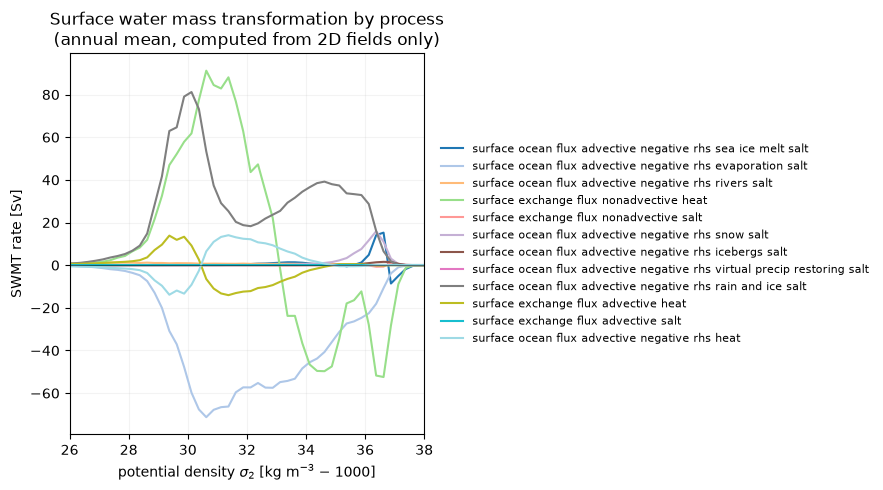

In [17]:
# kg/s -> Sv (1 Sv = 1e6 m^3/s), using the Boussinesq reference density.
kg_per_s_to_Sv = 1e-6 / 1035.

# The per-component terms, i.e. the ones carrying a `_heat`/`_salt` suffix. There are
# more of them than matplotlib's default 10-colour cycle, which would silently give two
# pairs of curves the same colour, so take colours from a 20-colour map instead.
components = [v for v in G if ("salt" in v) or ("heat" in v)]
colors = plt.cm.tab20(np.linspace(0., 1., len(components)))

fig, ax = plt.subplots(figsize=(9, 5))

for v, color in zip(components, colors):
    (G[v] * kg_per_s_to_Sv).mean('time').plot(ax=ax, label=v.replace("_", " "),
                                              lw=1.5, color=color)

ax.axhline(0., color='k', lw=0.8, alpha=0.5)
ax.set_xlim(26, 38)
ax.set_xlabel(r"potential density $\sigma_{2}$ [kg m$^{-3}$ $-$ 1000]")
ax.set_ylabel("SWMT rate [Sv]")
ax.set_title("Surface water mass transformation by process\n(annual mean, computed from 2D fields only)")
ax.grid(True, alpha=0.15)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
fig.tight_layout()

Each curve is one process's heat or salt contribution to transforming water across $\sigma_{2}$
surfaces — all of it recovered from surface fields alone. The largest are the non-advective
surface heat flux (+91 Sv, and $-52$ Sv at the dense end) and two freshwater terms,
rain-and-ice ($+81$ Sv) and evaporation ($-71$ Sv), and they substantially oppose one another: the net transformation is a
residual of terms several times its own size, which is exactly why the decomposition is worth
doing.

Remember what this figure is and is not. It is the transformation driven by *surface fluxes*,
computed under the assumption that those fluxes converge in the outcropping layer. It contains
no interior mixing, because this dataset contains no interior. To close a full transformation
budget — surface fluxes *and* interior processes, summing to the tendency of water mass volume
— see [closed_transformation_budget.ipynb](./closed_transformation_budget.ipynb).